# Medical Image Analysis for Pneumonia Detection using Deep Learning

## 1. Introduction
This project develops a medical image classification system for detecting pneumonia from chest X‑ray images using deep learning. The dataset contains 5,863 clinically validated X‑ray images categorized into **Normal (Healthy) indicated by probability close to 0** and **Pneumonia (Opacity) probability close to 1**.

## 2. Objective
- Apply image preprocessing for improved input quality  
- Implement deep learning models for classification  
- Explore transfer learning approaches  
- Combine models using meta‑learning (stacking)  
- Evaluate ensemble performance  

## 3. Methodology
Pipeline:  
**Input Image → Preprocessing → Segmentation → Deep Learning Models → Meta‑Learner → Final Prediction**

## 4. Image Preprocessing
- Resize to 224 × 224 pixels  
- Normalize pixel values to [0,1]  
- Apply Gaussian blur for noise reduction  
- Ensure consistent 3‑channel input  

## 5. Segmentation and ROI Extraction
- Convert to grayscale  
- Thresholding for binary masks  
- Contour detection for ROI  
- Bounding box extraction to isolate lung regions  

## 6. Post‑Processing
- Morphological operations (opening/closing)  
- Remove small noisy regions  
- Refine ROI quality  

## 7. Deep Learning Models
1. **Custom CNN** – built from scratch, learns spatial features  
2. **MobileNetV2 (Transfer Learning)** – pre‑trained on ImageNet, frozen layers  
3. **ResNet50 (Transfer Learning)** – residual connections, deeper feature extraction  
4. **Fine‑Tuned MobileNetV2** – frozen initially, then last layers unfrozen for adaptation  

## 8. Model Training
- Loss: Binary Crossentropy  
- Optimizer: Adam  
- Metric: Accuracy  
- Early stopping and checkpointing applied  

## 9. Ensemble Learning (Meta‑Learner)
- **Step 1:** Base models generate predictions  
- **Step 2:** Predictions concatenated into meta‑features  
- **Step 3:** Meta‑learner (small neural net) trained to combine predictions effectively  

## 10. Inference Pipeline
`Image → Preprocessing → Base Models → Meta Model → Final Prediction`

## 11. Results
- Transfer learning models outperformed custom CNN  
- Fine‑tuned MobileNet adapted better to medical data  
- Ensemble learning improved stability  
- Meta‑learner outperformed simple averaging  

## 12. Key Learnings
- Preprocessing strongly impacts performance  
- Segmentation focuses models on relevant regions  
- Transfer learning is effective for medical imaging  
- Ensemble/meta‑learning improves generalization  

## 13. Limitations
- Dataset imbalance may cause bias  
- Segmentation method is basic (threshold‑based)  
- No 3D or multi‑slice data used  
- Computational limits restricted experiments  

## 14. Future Work
- Explore 2.5D/3D CNNs  
- Use advanced segmentation (U‑Net)  
- Apply Grad‑CAM for explainability  
- Expand dataset diversity  
- Use cross‑validation for robustness  

## 15. Conclusion
By integrating preprocessing, segmentation, transfer learning, and meta‑learning, this project demonstrates a robust pipeline for pneumonia detection from chest X‑rays.

## Code

In [1]:
import cv2
import numpy as np

def preprocess_image(img_path):
    img = cv2.imread(img_path)

    # Resize
    img = cv2.resize(img, (224, 224))

    # Gaussian Blur (noise removal)
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)

    # Normalize
    img_norm = img_blur / 255.0

    return img, img_norm

In [2]:
def clean_mask(mask):
    kernel = np.ones((5,5), np.uint8)

    opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    return closing

In [3]:
def get_best_contour(contours):
    # Filter out tiny contours (noise)
    filtered = [c for c in contours if cv2.contourArea(c) > 500]
    if filtered:
        return max(filtered, key=cv2.contourArea)
    return None

In [9]:
def classify_prediction(pred):
    # Adjusted threshold for more confidence
    if pred > 0.6:
        return "Diseased"
    else:
        return "Normal"

In [10]:
def segment_image(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Thresholding
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # Clean mask (postprocessing)
    mask = clean_mask(thresh)

    # Apply mask to original image
    segmented = cv2.bitwise_and(img, img, mask=mask)

    # Find contours (ROI)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Use best contour instead of blindly largest
    best = get_best_contour(contours)
    if best is None:
        return cv2.resize(img, (224, 224))  # fallback

    x, y, w, h = cv2.boundingRect(best)
    roi = segmented[y:y+h, x:x+w]

    roi = cv2.resize(roi, (224, 224))
    return roi

In [11]:
def register_image(img):
    rows, cols = img.shape[:2]

    # Simple shift transformation
    M = np.float32([[1, 0, 5], [0, 1, 5]])
    shifted = cv2.warpAffine(img, M, (cols, rows))

    return shifted

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

2026-04-03 17:15:04.095766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775236504.493852      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775236504.603347      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775236505.572015      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775236505.572056      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775236505.572060      55 computation_placer.cc:177] computation placer alr

In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

def build_transfer_model():
    base_model = MobileNetV2(weights='imagenet',
                             include_top=False,
                             input_shape=(224,224,3))

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [58]:
import matplotlib.pyplot as plt

def visualize(img, mask=None, roi=None):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img, cmap='gray')

    if mask :
        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask, cmap='gray')

    if roi : 
        plt.subplot(1,3,3)
        plt.title("ROI")
        plt.imshow(roi, cmap='gray')

    plt.show()

In [15]:
TRAIN_PATH = "/kaggle/input/datasets/pcbreviglieri/pneumonia-xray-images/train"
VAL_PATH   = "/kaggle/input/datasets/pcbreviglieri/pneumonia-xray-images/val"
TEST_PATH  = "/kaggle/input/datasets/pcbreviglieri/pneumonia-xray-images/test"

In [56]:
import os
import cv2
import numpy as np
from tqdm import tqdm

label_map = {
    "normal": 0,
    "opacity": 1
}

IMG_SIZE = 224


def process_dataset(base_path):
    images = []
    labels = []

    for category in ["normal", "opacity"]:
        folder = os.path.join(base_path, category)

        for img_name in tqdm(os.listdir(folder)):
            img_path = os.path.join(folder, img_name)

            try:
                img = cv2.imread(img_path)

                if img is None:
                    continue

                # 🔥 ===== YOUR PIPELINE =====
                original, norm = preprocess_image(img_path)
                roi = segment_image(original)
                registered = register_image(roi)

                final_img = cv2.resize(registered, (IMG_SIZE, IMG_SIZE))
                final_img = final_img / 255.0

                # Ensure 3 channels
                if len(final_img.shape) == 2:
                    final_img = np.stack([final_img]*3, axis=-1)

                images.append(final_img)
                labels.append(label_map[category])

                visualize(final_img, mask, roi)

            except Exception as e:
                continue

    return np.array(images), np.array(labels)

In [17]:
X_train, y_train = process_dataset(TRAIN_PATH)
X_val, y_val     = process_dataset(VAL_PATH)
X_test, y_test   = process_dataset(TEST_PATH)

100%|██████████| 390/390 [00:09<00:00, 42.41it/s]


In [21]:
y_train = y_train.reshape(-1,1)
y_val   = y_val.reshape(-1,1)
y_test  = y_test.reshape(-1,1)

In [22]:
model = build_cnn()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5


I0000 00:00:1775236749.764457     136 service.cc:152] XLA service 0x7cd6400072a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775236749.764517     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775236749.764525     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775236750.237658     136 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-03 17:19:13.327152: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-03 17:19:13.475231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/131 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.4531 - loss: 1.4228

I0000 00:00:1775236756.048849     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - accuracy: 0.8242 - loss: 0.4697 - val_accuracy: 0.9106 - val_loss: 0.2226
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.9469 - loss: 0.1394 - val_accuracy: 0.9058 - val_loss: 0.2323
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.9545 - loss: 0.1184 - val_accuracy: 0.9183 - val_loss: 0.2072
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9756 - loss: 0.0677 - val_accuracy: 0.9144 - val_loss: 0.2566
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9905 - loss: 0.0300 - val_accuracy: 0.9144 - val_loss: 0.3248


In [57]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import albumentations as A

label_map = {
    "normal": 0,
    "opacity": 1
}

IMG_SIZE = 224

# ✅ Augmentation pipeline (Albumentations)
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
    A.GaussianBlur(p=0.3)
])

# ✅ New segmentation function (renamed for transfer learning)
def segment_for_transfer(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # Morphological cleaning
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Apply mask
    segmented = cv2.bitwise_and(img, img, mask=mask)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # fallback

    # Filter + best contour
    filtered = [c for c in contours if cv2.contourArea(c) > 500]
    if not filtered:
        return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    best = max(filtered, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(best)
    roi = segmented[y:y+h, x:x+w]

    roi = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    return roi

# ✅ Dataset processing with augmentation
def process_dataset_transfer_xfer_learn(base_path):
    images = []
    labels = []

    for category in ["normal", "opacity"]:
        folder = os.path.join(base_path, category)

        for img_name in tqdm(os.listdir(folder)):
            img_path = os.path.join(folder, img_name)

            try:
                img = cv2.imread(img_path)
                if img is None:
                    continue

                roi = segment_for_transfer(img)

                # Normalize
                final_img = roi / 255.0

                # Ensure 3 channels
                if len(final_img.shape) == 2:
                    final_img = np.stack([final_img]*3, axis=-1)

                # Apply augmentation (Albumentations expects uint8)
                aug_img = augment(image=(final_img*255).astype(np.uint8))["image"]
                aug_img = aug_img.astype(np.float32) / 255.0

                images.append(aug_img)
                labels.append(label_map[category])

                visualize(aug_img, mask, roi)

            except Exception as e:
                continue

    return np.array(images), np.array(labels)


In [38]:
X_train, y_train = process_dataset_transfer_xfer_learn(TRAIN_PATH)
X_val, y_val     = process_dataset_transfer_xfer_learn(VAL_PATH)
X_test, y_test   = process_dataset_transfer_xfer_learn(TEST_PATH)

100%|██████████| 390/390 [00:08<00:00, 45.58it/s]


In [27]:
y_train = y_train.reshape(-1,1)
y_val   = y_val.reshape(-1,1)
y_test  = y_test.reshape(-1,1)

In [28]:
model_transferLearn = build_transfer_model()

history = model_transferLearn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=7,
    batch_size=32
)

2026-04-03 16:20:09.338780: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 950ms/step - accuracy: 0.8848 - loss: 0.2989 - val_accuracy: 0.9135 - val_loss: 0.2263
Epoch 2/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 909ms/step - accuracy: 0.9392 - loss: 0.1500 - val_accuracy: 0.9096 - val_loss: 0.2260
Epoch 3/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 909ms/step - accuracy: 0.9518 - loss: 0.1228 - val_accuracy: 0.9202 - val_loss: 0.2084
Epoch 4/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 906ms/step - accuracy: 0.9548 - loss: 0.1149 - val_accuracy: 0.9163 - val_loss: 0.2266
Epoch 5/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 925ms/step - accuracy: 0.9645 - loss: 0.0943 - val_accuracy: 0.9038 - val_loss: 0.3211
Epoch 6/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 122s 930ms/step - accuracy: 0.9625 - loss: 0.1003 - val_accuracy: 0.9202 - val_loss: 0.2542
Epoch 7/7
131/131 ━━━━━━━━━━━━━━━━━━━━ 127s 973ms/step - accuracy: 0.9705 - loss: 0.0791 - val_accuracy: 0.9125 - val_loss: 0.2696


In [23]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6427 - loss: 3.1592
Test Accuracy: 0.7932692170143127


In [77]:
loss, acc = model_transferLearn.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 715ms/step - accuracy: 0.5605 - loss: 1.6220
Test Accuracy: 0.7532051205635071


In [29]:
model_transferLearn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

## Testing Visualization using gradcam

In [61]:
import os
import cv2
import numpy as np
from tqdm import tqdm


IMG_SIZE = 224


def process_dataset_test_img_gradCam(img_path):

    img = cv2.imread(img_path)

    if img is None:
        raise ValueError("Image not found or cannot be read.") 

    original, norm = preprocess_image(img_path)
    roi = segment_image(original)
    registered = register_image(roi)
    
    final_img = cv2.resize(registered, (IMG_SIZE, IMG_SIZE))
    final_img = final_img.astype("float32") / 255.0

    # Ensure 3 channels
    if len(final_img.shape) == 2:
        final_img = np.stack([final_img]*3, axis=-1)

    # Add batch dimension for model input
    img_array = np.expand_dims(final_img, axis=0) # shape (1,224,224,3)

    return img_array, img

In [64]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Build a model that maps input -> activations of last conv layer + predictions
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Forward + backward pass
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradients of target class wrt conv layer output
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weighted sum of activations
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize between 0–1
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap.numpy()

def overlay_gradcam(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap = cv2.applyColorMap(heatmap, colormap)

    # Overlay
    overlay = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    return overlay


In [24]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

In [68]:
dummy = np.zeros((1,224,224,3), dtype=np.float32)
_ = model.predict(dummy)   # runs a forward pass, builds the graph


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


In [70]:
# Load and preprocess image
img_path = "/kaggle/input/datasets/pcbreviglieri/pneumonia-xray-images/test/opacity/person100_bacteria_478.jpeg"

img_array, img = process_dataset_test_img_gradCam(img_path)

# Generate heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv2d_2")

overlay = overlay_gradcam(original, heatmap)

plt.imshow(overlay)
plt.axis("off")
plt.show()

AttributeError: The layer sequential has never been called and thus has no defined output.

In [26]:
# Save entire model (architecture + weights + optimizer state)
#model.save("cnn_model.h5")   # creates a single HDF5 file

# Alternatively, save in TensorFlow SavedModel format
model.save("cnn_model.keras")   # creates a folder with model files


In [30]:
# Save entire model (architecture + weights + optimizer state)
model_transferLearn.save("MobileNet_model.h5")   # creates a single HDF5 file

# Alternatively, save in TensorFlow SavedModel format
model_transferLearn.save("MobileNet_model.keras")   # creates a folder with model files


## FineTune MobileNet

In [39]:
def build_mobilenet_finetune():
    base_model = MobileNetV2(weights='imagenet',
                             include_top=False,
                             input_shape=(224,224,3))

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    # Freeze most layers, unfreeze last 20
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Phase 1: train head only
model = build_mobilenet_finetune()   # with all layers frozen
history1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)

# Phase 2: unfreeze last N layers
for layer in model.layers[-20:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=[ModelCheckpoint("mobilenet_finetuned.keras", save_best_only=True)]
)


Epoch 1/5


2026-04-03 17:42:31.004597: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-03 17:42:31.140637: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7551 - loss: 0.5215

2026-04-03 17:42:54.335576: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-03 17:42:54.472245: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


131/131 ━━━━━━━━━━━━━━━━━━━━ 42s 164ms/step - accuracy: 0.7556 - loss: 0.5208 - val_accuracy: 0.7490 - val_loss: 0.5391
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9170 - loss: 0.2573 - val_accuracy: 0.7625 - val_loss: 0.5742
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9324 - loss: 0.2039 - val_accuracy: 0.7663 - val_loss: 0.6072
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - accuracy: 0.9061 - loss: 0.2657 - val_accuracy: 0.7596 - val_loss: 0.6147
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9300 - loss: 0.1870 - val_accuracy: 0.7673 - val_loss: 0.6284
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9424 - loss: 0.1517 - val_accuracy: 0.7846 - val_loss: 0.5791
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9557 - loss: 0.1254 - val_accuracy: 0.8058 - val_loss: 0.5219
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9588 - loss: 0.1157 - val_accuracy: 0.8

In [42]:
model.save('FineTuneMobileNet.keras')
model.save('FineTuneMobileNet.h5')

In [44]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def build_resnet_model():
    base_model = ResNet50(weights='imagenet',
                          include_top=False,
                          input_shape=(224,224,3))

    # Add custom head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)   # optional regularization
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    # Freeze base layers initially
    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [45]:
model_transferLearn_RestNet50 = build_resnet_model()

history = model_transferLearn_RestNet50.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 172ms/step - accuracy: 0.7108 - loss: 0.6275 - val_accuracy: 0.7423 - val_loss: 0.5199
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.7568 - loss: 0.5183 - val_accuracy: 0.7663 - val_loss: 0.5041
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.7729 - loss: 0.4856 - val_accuracy: 0.7692 - val_loss: 0.4834
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.7851 - loss: 0.4765 - val_accuracy: 0.8077 - val_loss: 0.4940
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - accuracy: 0.8070 - loss: 0.4431 - val_accuracy: 0.7894 - val_loss: 0.4544
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.7978 - loss: 0.4437 - val_accuracy: 0.8279 - val_loss: 0.4746
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - accuracy: 0.7835 - loss: 0.4606 - val_accuracy: 0.8135 - val_loss: 0.4457
Epoch 8/10
131/131 ━━━━━━━━━━━━━

In [46]:
loss, acc = model_transferLearn_RestNet50.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5493 - loss: 0.8250
Test Accuracy: 0.7435897588729858


In [48]:
model_transferLearn_RestNet50.save('model_transferLearn_RestNet50.keras')
model_transferLearn_RestNet50.save('model_transferLearn_RestNet50.h5')

In [47]:
model_transferLearn_RestNet50.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_7[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,374,917 (92.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 524,804 (2.00 MB)

In [71]:
import matplotlib.pyplot as plt

def visualize_prediction(img_path):
    # --- Original image ---
    original = cv2.imread(img_path)
    if original is None:
        raise ValueError("Image not found or cannot be read.")
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # --- Preprocessed images ---
    img, _ = process_single_image(img_path)
    img_cnn, _ = process_single_image_cnn(img_path)

    # Remove batch dimension for visualization
    preproc_rgb = (img[0] * 255).astype(np.uint8)
    preproc_cnn_rgb = (img_cnn[0] * 255).astype(np.uint8)

    # --- Predictions ---
    p1 = cnn_model.predict(img_cnn)
    p2 = mobilenet_model.predict(img)
    p3 = resnet_model.predict(img)
    p4 = mobilenet_ft_model.predict(img)

    meta_input = np.concatenate([p1, p2, p3, p4], axis=1)
    final_pred = meta_model.predict(meta_input)
    final_label = (final_pred > 0.5).astype(int)
    label_text = "PNEUMONIA" if final_label[0][0] == 1 else "NORMAL"

    # --- Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(15,5))

    axes[0].imshow(original_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(preproc_rgb)
    axes[1].set_title("Preprocessed (Transfer)")
    axes[1].axis("off")

    axes[2].imshow(preproc_cnn_rgb)
    axes[2].set_title("Preprocessed (CNN)")
    axes[2].axis("off")

    plt.suptitle(f"Meta Prediction: {label_text} (Raw={final_pred[0][0]:.4f})", fontsize=14)
    plt.show()

    return final_pred, final_label


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


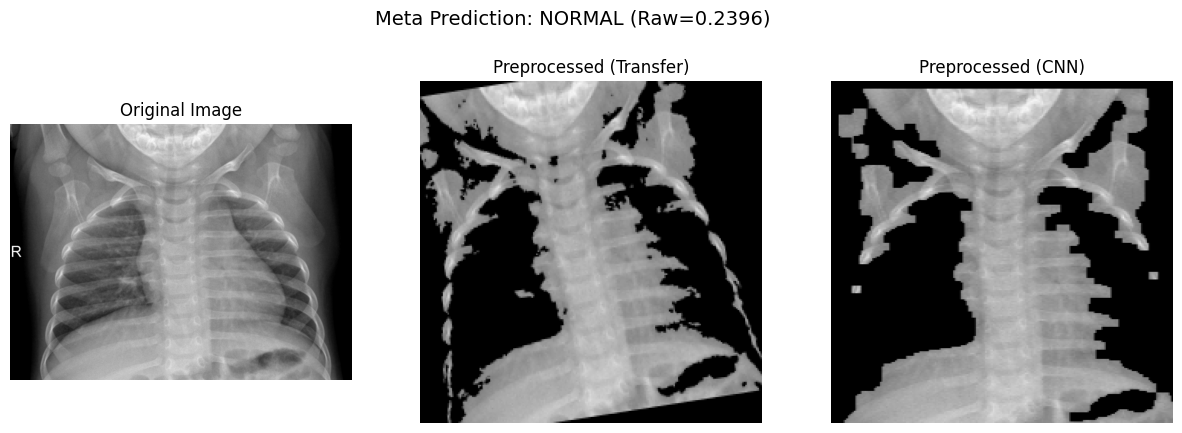

(array([[0.2396492]], dtype=float32), array([[0]]))

In [75]:
#img_path = '/kaggle/input/datasets/pcbreviglieri/pneumonia-xray-images/train/opacity/person1002_bacteria_2933.jpeg'
#img_path = "/kaggle/input/datasets/pcbreviglieri/pneumonia-xray-images/val/opacity/person1399_bacteria_3549.jpeg"
img_path = "/kaggle/input/datasets/pcbreviglieri/pneumonia-xray-images/val/normal/NORMAL2-IM-1056-0001.jpeg"

visualize_prediction(img_path)